In [11]:
# Cell 1: imports and display options

import pandas as pd
import numpy as np
import matplotlib.pylab as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 120)


In [13]:

import seaborn as sns
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn import preprocessing
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

In [15]:
def evaluateBinaryClassification(predictions, actuals):
    contigency = pd.crosstab(actuals, predictions)

    print(contigency)  # 👈 always print to debug

    labels = contigency.index.tolist()

    TP = contigency.loc[labels[1], labels[1]]
    TN = contigency.loc[labels[0], labels[0]]
    FP = contigency.loc[labels[0], labels[1]]
    FN = contigency.loc[labels[1], labels[0]]

    print("TP:", TP, "TN:", TN, "FP:", FP, "FN:", FN)

In [17]:
import os
os.chdir('/Users/zolf/Desktop/T1')

In [19]:
df = pd.read_csv("AQ_predatoria.csv", sep=";", decimal=",")

In [21]:
print("Shape:", df.shape)
df.head()

Shape: (165, 42)


,ID,MAOAuVNTR,Eta,QI,adhd,farmaco,cse,emotional,neglect,physical,AD,RBB,AB,TOTINT,TOTEXT,APQ_POS,APQ_NEG,APSD_CU,APSD_IMP,APSD_NARCI,Sintomi_DOP,ER_paura,ER_tristezza,ER_rabbia,ER_felicità,ER_disgusto,FC_E_AN,FC_E_HA,FC_E_SA,FC_E_FE,FC_E_DI,FFD_E_AN,FFD_E_HA,FFD_E_SA,FFD_E_FE,FFD_E_DI,FD_E_AN,FD_E_HA,FD_E_SA,FD_E_FE,FD_E_DI,AQ_Predatoria1
0,1,"4,0",7,122,1,2,3,1,1,1,55,63,65,57,64,48,13,4,4,4,7,0,3,3,4,4,"27,27","19,82","15,82","27,74","22,60","216,85","229,38","262,78","243,70","308,48","31,31","23,27","19,98","29,42","27,68",1.0
1,2,"4,0",9,90,1,1,2,2,1,1,73,63,70,68,68,52,20,1,6,4,5,3,5,3,4,0,"52,90","52,15","73,61","75,76","58,88","127,23","215,43","221,03","160,28","168,73","54,45","50,27","76,11","73,37","61,44",0.0
2,3,"3,0",10,97,1,1,2,1,1,1,70,71,81,72,75,56,20,4,7,5,4,2,1,2,4,4,"34,40","17,11","44,34","44,71","29,29","190,65","188,25","195,35","165,10","189,10","35,74","15,79","43,01","40,00","26,80",2.0
3,4,"4,0",7,111,2,2,4,1,1,1,57,53,64,50,61,52,14,4,5,3,6,4,2,4,3,0,"51,83","46,88","55,83","42,92","44,06","152,20","154,30","156,35","133,38","235,65","51,62","43,47","50,55","47,68","44,38",0.0
4,5,"3,0",9,100,1,1,3,1,1,1,82,64,70,75,70,52,11,4,5,2,5,4,3,3,4,3,"45,20","16,67","44,83","19,52","19,29","161,03","68,85","164,93","80,20","94,05","46,86","15,98","45,78","17,79","19,04",1.0


In [23]:
# Cell 3: clean column names 

# strip leading/trailing spaces and remove internal spaces
df.columns = df.columns.str.strip().str.replace(r"\s+", "", regex=True)

print("Column names after cleaning:")
print(df.columns.tolist())


Column names after cleaning:
['ID', 'MAOAuVNTR', 'Eta', 'QI', 'adhd', 'farmaco', 'cse', 'emotional', 'neglect', 'physical', 'AD', 'RBB', 'AB', 'TOTINT', 'TOTEXT', 'APQ_POS', 'APQ_NEG', 'APSD_CU', 'APSD_IMP', 'APSD_NARCI', 'Sintomi_DOP', 'ER_paura', 'ER_tristezza', 'ER_rabbia', 'ER_felicità', 'ER_disgusto', 'FC_E_AN', 'FC_E_HA', 'FC_E_SA', 'FC_E_FE', 'FC_E_DI', 'FFD_E_AN', 'FFD_E_HA', 'FFD_E_SA', 'FFD_E_FE', 'FFD_E_DI', 'FD_E_AN', 'FD_E_HA', 'FD_E_SA', 'FD_E_FE', 'FD_E_DI', 'AQ_Predatoria1']


In [25]:
# Cell 4: replace weird placeholders with NaN

placeholders = ['#NULL!', 'NULL', 'NaN', 'NA', 'n/a', 'N/A', ' ', '']
df = df.replace(placeholders, np.nan)

print("Done replacing placeholders. Any NaNs now:", df.isna().sum().sum())


Done replacing placeholders. Any NaNs now: 841


In [27]:
# Cell 5: fix numeric-like columns (commas, percents)

for col in df.columns:
    s = df[col].astype(str)

    # If there are % values → remove % and convert comma to dot
    if s.str.contains('%').any():
        s = s.str.replace('%', '', regex=False).str.replace(',', '.', regex=False)
        df[col] = pd.to_numeric(s, errors='coerce')
    
    # Else, if there are commas but no % → treat as decimal comma
    elif s.str.contains(',').any():
        s = s.str.replace(',', '.', regex=False)
        df[col] = pd.to_numeric(s, errors='coerce')

    # Otherwise, try numeric conversion but don't force
    else:
        try:
            df[col] = pd.to_numeric(df[col], errors='ignore')
        except Exception:
            pass

print("Dtypes after numeric cleaning:")
print(df.dtypes)


Dtypes after numeric cleaning:
ID                  int64
MAOAuVNTR         float64
Eta               float64
QI                float64
adhd              float64
farmaco           float64
cse               float64
emotional         float64
neglect           float64
physical          float64
AD                  int64
RBB                 int64
AB                  int64
TOTINT              int64
TOTEXT              int64
APQ_POS           float64
APQ_NEG           float64
APSD_CU             int64
APSD_IMP            int64
APSD_NARCI          int64
Sintomi_DOP       float64
ER_paura          float64
ER_tristezza      float64
ER_rabbia         float64
ER_felicità       float64
ER_disgusto       float64
FC_E_AN           float64
FC_E_HA           float64
FC_E_SA           float64
FC_E_FE           float64
FC_E_DI           float64
FFD_E_AN          float64
FFD_E_HA          float64
FFD_E_SA          float64
FFD_E_FE          float64
FFD_E_DI          float64
FD_E_AN           float64
FD_E_HA

In [29]:
# Cell 6: define column groups

# main continuous targets
target_cont = ['AQ_Predatoria1']

# gene variant (categorical)
gene_vars = ['MAOAuVNTR']

# categorical clinical-like variables
class_vars = ['adhd', 'farmaco', 'cse', 'emotional', 'neglect', 'physical']

# eye-tracking metrics
eye_tracking_vars = [
    'FC_E_AN', 'FC_E_HA', 'FC_E_SA', 'FC_E_FE', 'FC_E_DI',
    'FFD_E_AN', 'FFD_E_HA', 'FFD_E_SA', 'FFD_E_FE', 'FFD_E_DI',
    'FD_E_AN', 'FD_E_HA', 'FD_E_SA', 'FD_E_FE', 'FD_E_DI'
]

# emotion recognition variables
er_cols = ['ER_paura', 'ER_tristezza', 'ER_rabbia', 'ER_felicità', 'ER_disgusto']

# other numeric-like vars you mentioned
other_numeric = ['Eta', 'QI', 'APQ_POS', 'APQ_NEG', 'Sintomi_DOP']

print("Targets:", target_cont)
print("Eye-tracking vars:", eye_tracking_vars)


Targets: ['AQ_Predatoria1']
Eye-tracking vars: ['FC_E_AN', 'FC_E_HA', 'FC_E_SA', 'FC_E_FE', 'FC_E_DI', 'FFD_E_AN', 'FFD_E_HA', 'FFD_E_SA', 'FFD_E_FE', 'FFD_E_DI', 'FD_E_AN', 'FD_E_HA', 'FD_E_SA', 'FD_E_FE', 'FD_E_DI']


In [31]:
# Cell 7: ensure numeric where expected

numeric_like = target_cont + eye_tracking_vars + er_cols + other_numeric

for col in numeric_like:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print("Numeric-like columns converted. Sample dtypes:")
print(df[numeric_like].dtypes.dropna())


Numeric-like columns converted. Sample dtypes:
AQ_Predatoria1    float64
FC_E_AN           float64
FC_E_HA           float64
FC_E_SA           float64
FC_E_FE           float64
FC_E_DI           float64
FFD_E_AN          float64
FFD_E_HA          float64
FFD_E_SA          float64
FFD_E_FE          float64
FFD_E_DI          float64
FD_E_AN           float64
FD_E_HA           float64
FD_E_SA           float64
FD_E_FE           float64
FD_E_DI           float64
ER_paura          float64
ER_tristezza      float64
ER_rabbia         float64
ER_felicità       float64
ER_disgusto       float64
Eta               float64
QI                float64
APQ_POS           float64
APQ_NEG           float64
Sintomi_DOP       float64
dtype: object


In [33]:
# Cell 8: handle missing values

# numeric columns
num_cols = df.select_dtypes(include=['number']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# categorical / object columns
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].mode()[0])

print("Total missing values after filling:", df.isna().sum().sum())


Total missing values after filling: 0


In [35]:
# Cell 9: create binary targets from continuous targets

for col in target_cont:
    if col in df.columns:
        median_val = df[col].median()
        df[col + '_binary'] = (df[col] > median_val).astype(int)
        print(f"{col}: median = {median_val:.3f}")

print("\nBinary target columns created:")
print([c for c in df.columns if c.endswith('_binary')])


AQ_Predatoria1: median = 1.000

Binary target columns created:
['AQ_Predatoria1_binary']


In [37]:
# Cell 10: check distributions of binary targets

binary_targets = [c for c in df.columns if c.endswith('_binary')]
for col in binary_targets:
    print(f"\n{col} value counts:")
    print(df[col].value_counts())



AQ_Predatoria1_binary value counts:
AQ_Predatoria1_binary
0    125
1     40
Name: count, dtype: int64


In [39]:
# Cell 11: build X and y_clf (features and classification targets)

target_bin = [c for c in df.columns if c.endswith('_binary')]
all_targets = target_cont + target_bin

# ID-like columns to exclude if present
id_like = ['ID', 'Nome', 'Unnamed:0', 'Unnamed:1']

exclude_cols = all_targets + id_like
feature_cols = [c for c in df.columns if c not in exclude_cols]

X = df[feature_cols].copy()
y = df[target_bin].copy()

print("Feature columns:", len(feature_cols))
print("Classification targets:", target_bin)


Feature columns: 40
Classification targets: ['AQ_Predatoria1_binary']


In [61]:
from sklearn.model_selection import train_test_split

# First split: train+val vs test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=1
)

# Second split: train vs validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=1
)
# 60% train, 20% val, 20% test

# Convert to 1D
y_train_1d = y_train.iloc[:, 0]
y_val_1d   = y_val.iloc[:, 0]
y_test_1d  = y_test.iloc[:, 0]

In [45]:
from sklearn.neural_network import MLPClassifier
import warnings

warnings.filterwarnings("ignore")

In [63]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.neural_network import MLPClassifier

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(random_state=5))
])

param_grid = {
    'mlp__hidden_layer_sizes': [(5,), (10,), (20,), (10,5), (20,10)],
    'mlp__activation': ['relu', 'tanh'],
    'mlp__solver': ['adam'],
    'mlp__alpha': [0.0001, 0.001, 0.01],
    'mlp__learning_rate_init': [0.0001, 0.001, 0.01],
    'mlp__max_iter': [500],
    'mlp__early_stopping': [True]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

gridSearch = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=2
)

gridSearch.fit(X_train, y_train_1d)

best_model = gridSearch.best_estimator_

Fitting 5 folds for each of 90 candidates, totalling 450 fits


In [65]:
import numpy as np
from sklearn.metrics import f1_score

y_val_prob = best_model.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.05)

best_t = 0.5
best_f1 = 0

for t in thresholds:
    y_val_pred = (y_val_prob > t).astype(int)
    f1 = f1_score(y_val_1d, y_val_pred)
    
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("Best threshold:", best_t)
print("Validation F1:", best_f1)

Best threshold: 0.4500000000000001
Validation F1: 0.56


In [67]:
from sklearn.metrics import classification_report

y_test_prob = best_model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_prob > best_t).astype(int)

print(classification_report(y_test_1d, y_test_pred))

              precision    recall  f1-score   support

           0       0.89      0.64      0.74        25
           1       0.40      0.75      0.52         8

    accuracy                           0.67        33
   macro avg       0.64      0.70      0.63        33
weighted avg       0.77      0.67      0.69        33



In [53]:
import numpy as np
from sklearn.metrics import f1_score

thresholds = np.arange(0.1, 0.9, 0.05)
best_f1 = 0
best_t = 0.5

for t in thresholds:
    y_pred = (y_prob > t).astype(int)
    f1 = f1_score(y_test_1d, y_pred)
    
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print(best_t, best_f1)

0.30000000000000004 0.45454545454545453


In [57]:
def evaluateBinaryClassification(predictions, actuals):
    contingency = pd.crosstab(actuals, predictions)

    for val in [0, 1]:
        if val not in contingency.index:
            contingency.loc[val] = 0
        if val not in contingency.columns:
            contingency[val] = 0

    contingency = contingency.sort_index().sort_index(axis=1)

    TN = contingency.loc[0, 0]
    FP = contingency.loc[0, 1]
    FN = contingency.loc[1, 0]
    TP = contingency.loc[1, 1]

    accuracy = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    print("Confusion Matrix:\n", contingency)
    print(f"\nTP: {TP}, TN: {TN}, FP: {FP}, FN: {FN}")
    print(f"\nAccuracy: {accuracy:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"F1-score: {f1:.3f}")

    return TP, TN, FP, FN, accuracy, precision, recall, f1

In [59]:
y_pred = best_model.predict(X_test)

TP, TN, FP, FN, acc, prec, rec, f1 = evaluateBinaryClassification(y_pred, y_test_1d)

Confusion Matrix:
 col_0                   0  1
AQ_Predatoria1_binary       
0                      21  4
1                       5  3

TP: 3, TN: 21, FP: 4, FN: 5

Accuracy: 0.727
Precision: 0.429
Recall: 0.375
F1-score: 0.400


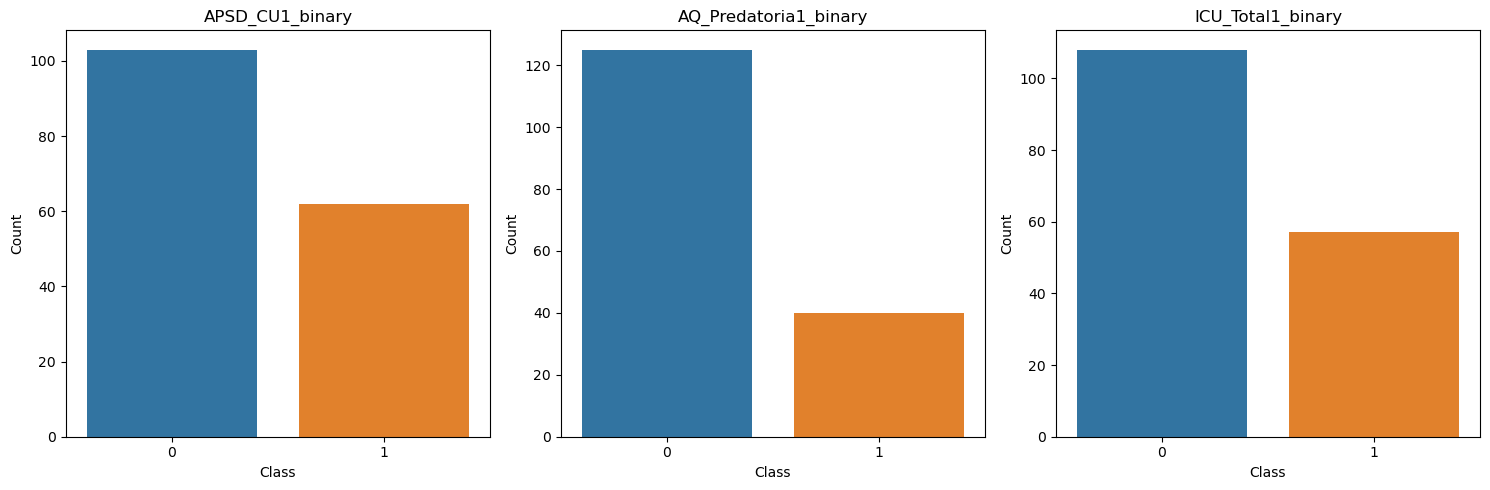

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

# Data
data = {
    "APSD_CU1_binary": {0: 103, 1: 62},
    "AQ_Predatoria1_binary": {0: 125, 1: 40},
    "ICU_Total1_binary": {0: 108, 1: 57}
}

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (title, counts) in zip(axes, data.items()):
    sns.barplot(x=list(counts.keys()), y=list(counts.values()), ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Class")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

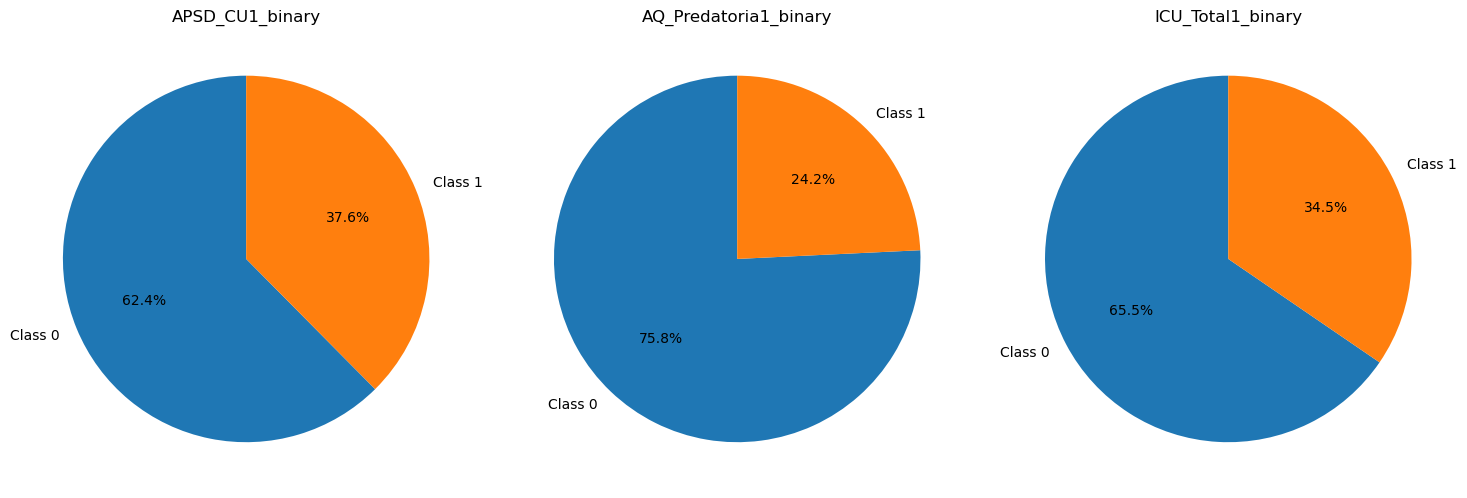

In [73]:
import matplotlib.pyplot as plt

# Data
data = {
    "APSD_CU1_binary": [103, 62],
    "AQ_Predatoria1_binary": [125, 40],
    "ICU_Total1_binary": [108, 57]
}

labels = ['Class 0', 'Class 1']

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (title, values) in zip(axes, data.items()):
    ax.pie(values, labels=labels, autopct='%1.1f%%', startangle=90)
    ax.set_title(title)

plt.tight_layout()
plt.show()

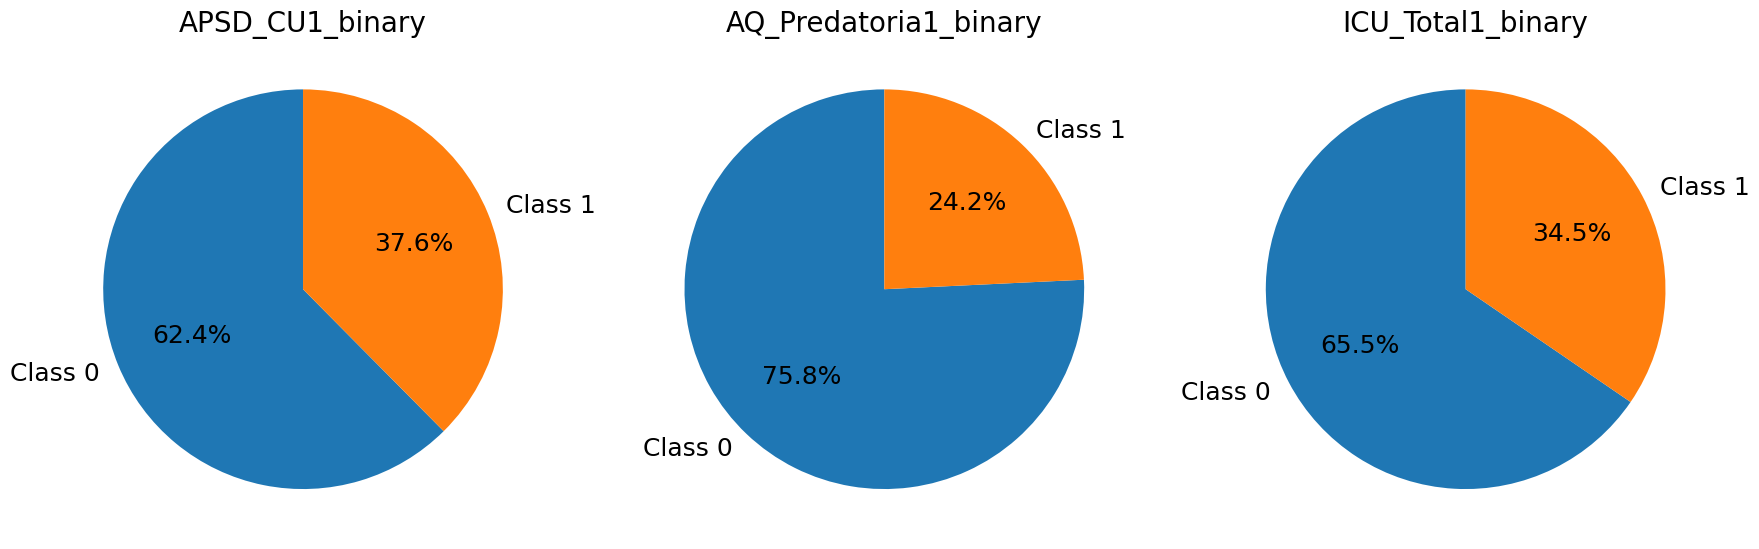

In [157]:
import matplotlib.pyplot as plt

# Data
data = {
    "APSD_CU1_binary": [103, 62],
    "AQ_Predatoria1_binary": [125, 40],
    "ICU_Total1_binary": [108, 57]
}

labels = ['Class 0', 'Class 1']

# Global font size (optional but useful)
plt.rcParams.update({'font.size': 14})

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (title, values) in zip(axes, data.items()):
    ax.pie(
        values,
        labels=labels,
        autopct='%1.1f%%',
        startangle=90,
        textprops={'fontsize': 18}  # 👈 controls label + percentage size
    )
    ax.set_title(title, fontsize=20)  # 👈 bigger title

plt.tight_layout()
plt.show()

In [119]:
# Metrics for each target
metrics_APSD = [0.758, 0.500, 0.500, 0.500]
metrics_AQ   = [0.727, 0.429, 0.375, 0.400]
metrics_ICU  = [0.636, 0.400, 0.400, 0.400]

labels = ['Accuracy', 'Precision', 'Recall', 'F1-score']

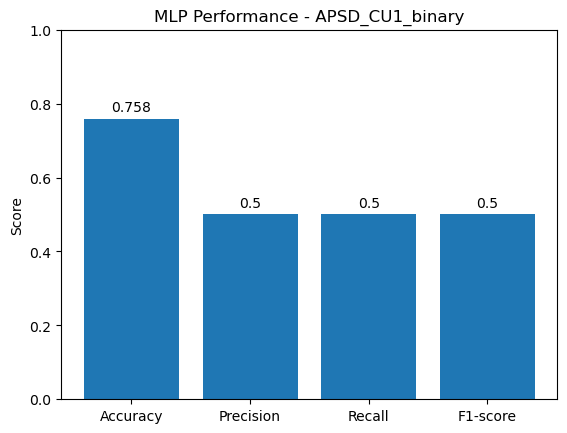

In [121]:
plt.figure()
plt.bar(labels, metrics_APSD)
plt.title('MLP Performance - APSD_CU1_binary')
plt.ylabel('Score')
plt.ylim(0, 1)

for i, v in enumerate(metrics_APSD):
    plt.text(i, v + 0.02, str(v), ha='center')

plt.show()

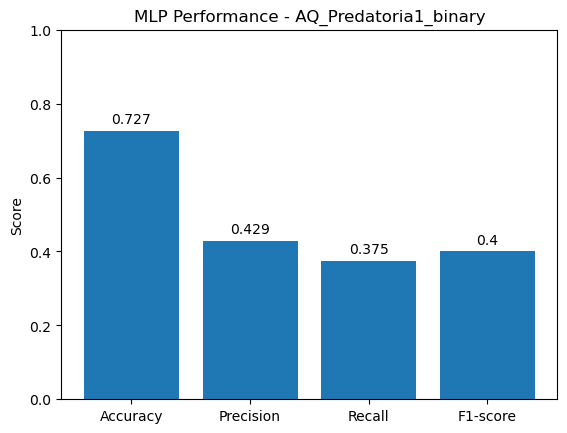

In [123]:
plt.figure()
plt.bar(labels, metrics_AQ)
plt.title('MLP Performance - AQ_Predatoria1_binary')
plt.ylabel('Score')
plt.ylim(0, 1)

for i, v in enumerate(metrics_AQ):
    plt.text(i, v + 0.02, str(v), ha='center')

plt.show()

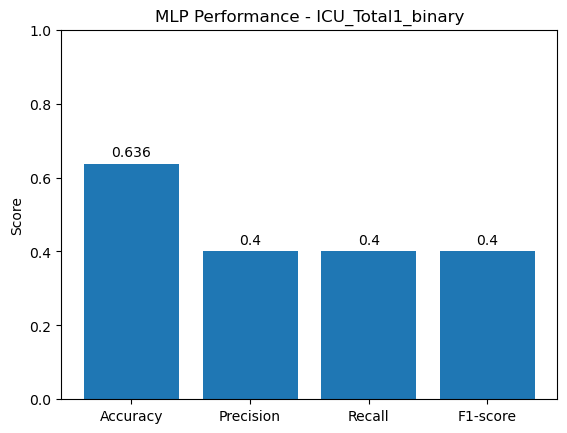

In [125]:
plt.figure()
plt.bar(labels, metrics_ICU)
plt.title('MLP Performance - ICU_Total1_binary')
plt.ylabel('Score')
plt.ylim(0, 1)

for i, v in enumerate(metrics_ICU):
    plt.text(i, v + 0.02, str(v), ha='center')

plt.show()

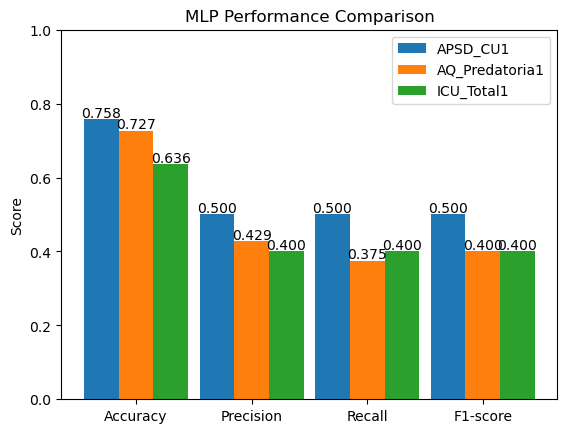

In [137]:
import matplotlib.pyplot as plt
import numpy as np

# Labels
labels = ['Accuracy', 'Precision', 'Recall', 'F1-score']

# Data
metrics_APSD = [0.758, 0.500, 0.500, 0.500]
metrics_AQ   = [0.727, 0.429, 0.375, 0.400]
metrics_ICU  = [0.636, 0.400, 0.400, 0.400]

x = np.arange(len(labels))  # positions
width = 0.3  # width of bars

plt.figure()

# Bars
bars1 = plt.bar(x - width, metrics_APSD, width, label='APSD_CU1')
bars2 = plt.bar(x,         metrics_AQ,   width, label='AQ_Predatoria1')
bars3 = plt.bar(x + width, metrics_ICU,  width, label='ICU_Total1')

# Labels & title
plt.ylabel('Score')
plt.title('MLP Performance Comparison')
plt.xticks(x, labels)
plt.ylim(0, 1)
plt.legend()

# Add values on top
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.005,
                 f'{height:.3f}', ha='center')

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)

plt.show()

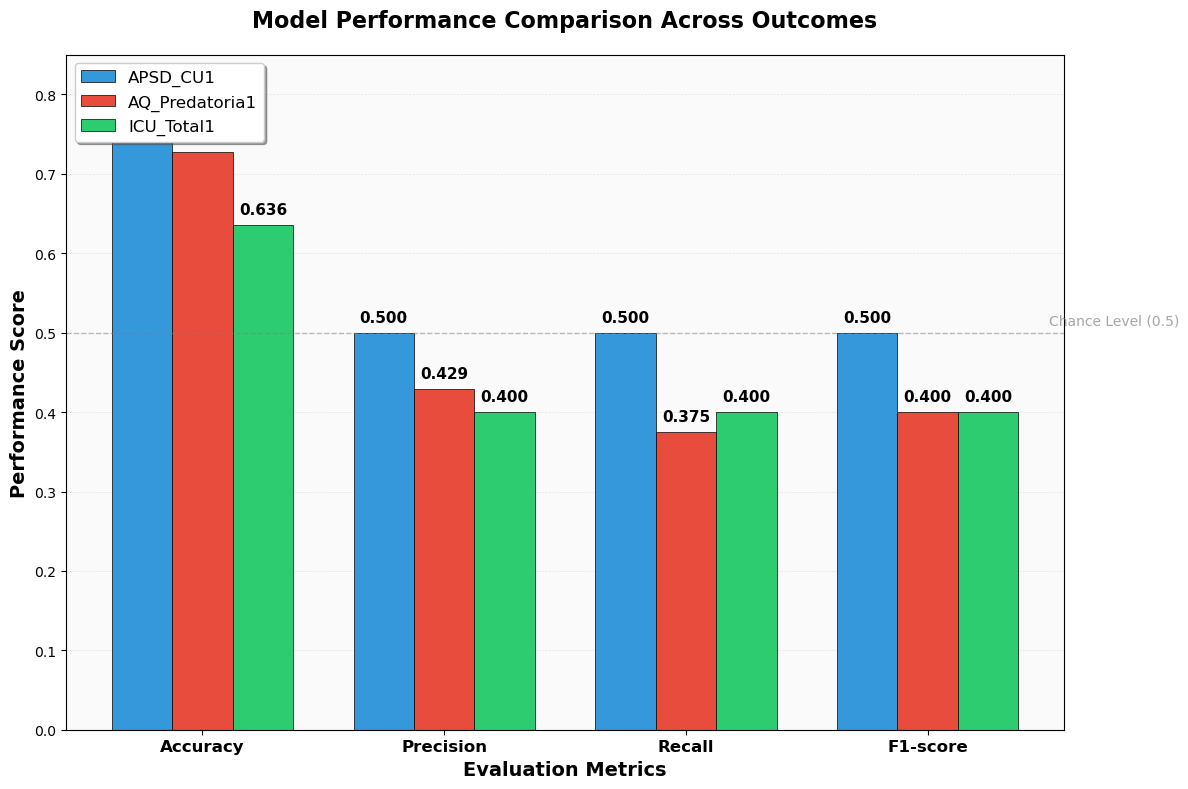


MODEL PERFORMANCE SUMMARY
Metric       APSD_CU1     AQ_Predatoria1  ICU_Total1  
----------------------------------------------------------------------
Accuracy     0.758        0.727           0.636       
Precision    0.500        0.429           0.400       
Recall       0.500        0.375           0.400       
F1-score     0.500        0.400           0.400       
----------------------------------------------------------------------

Best performing model by metric:
  Accuracy: APSD_CU1 (0.758)
  Precision: APSD_CU1 (0.500)
  Recall: APSD_CU1 (0.500)
  F1-score: APSD_CU1 (0.500)


In [139]:
import matplotlib.pyplot as plt
import numpy as np

# Data from your table
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
models = ['APSD_CU1', 'AQ_Predatoria1', 'ICU_Total1']

# Performance data
data = {
    'APSD_CU1': [0.758, 0.500, 0.500, 0.500],
    'AQ_Predatoria1': [0.727, 0.429, 0.375, 0.400],
    'ICU_Total1': [0.636, 0.400, 0.400, 0.400]
}

# Set up the figure with larger size
fig, ax = plt.subplots(figsize=(12, 8))

# Set the width of bars and positions
bar_width = 0.25
x_pos = np.arange(len(metrics))

# Create bars with distinct colors
bars1 = ax.bar(x_pos - bar_width, data['APSD_CU1'], bar_width, 
               label='APSD_CU1', color='#3498db', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x_pos, data['AQ_Predatoria1'], bar_width, 
               label='AQ_Predatoria1', color='#e74c3c', edgecolor='black', linewidth=0.5)
bars3 = ax.bar(x_pos + bar_width, data['ICU_Total1'], bar_width, 
               label='ICU_Total1', color='#2ecc71', edgecolor='black', linewidth=0.5)

# Add value labels on top of bars with larger font and no overlap
def add_labels(bars, offset=0):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.01, 
                f'{height:.3f}', 
                ha='center', va='bottom', fontsize=11, fontweight='bold',
                rotation=0)

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)

# Customize the plot with larger fonts
ax.set_ylabel('Performance Score', fontsize=14, fontweight='bold')
ax.set_xlabel('Evaluation Metrics', fontsize=14, fontweight='bold')
ax.set_title('Model Performance Comparison Across Outcomes', 
             fontsize=16, fontweight='bold', pad=20)

# Set x-axis ticks and labels with larger font
ax.set_xticks(x_pos)
ax.set_xticklabels(metrics, fontsize=12, fontweight='bold')

# Set y-axis limits to accommodate labels (add space at top)
ax.set_ylim(0, 0.85)

# Add grid for better readability
ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)

# Add legend with larger font
ax.legend(loc='upper left', fontsize=12, frameon=True, fancybox=True, shadow=True)

# Add a light background color
ax.set_facecolor('#fafafa')

# Add horizontal line at 0.5 for reference (chance level)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, linewidth=1, label='Chance Level (0.5)')

# Add annotation for chance level
ax.text(3.5, 0.51, 'Chance Level (0.5)', fontsize=10, color='gray', alpha=0.7)

# Adjust layout
plt.tight_layout()

# Save figure
plt.savefig('model_performance_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('model_performance_comparison.pdf', bbox_inches='tight', facecolor='white')

plt.show()

# ============================================
# PRINT SUMMARY TABLE
# ============================================
print("\n" + "="*70)
print("MODEL PERFORMANCE SUMMARY")
print("="*70)
print(f"{'Metric':<12} {'APSD_CU1':<12} {'AQ_Predatoria1':<15} {'ICU_Total1':<12}")
print("-"*70)

for i, metric in enumerate(metrics):
    print(f"{metric:<12} {data['APSD_CU1'][i]:<12.3f} {data['AQ_Predatoria1'][i]:<15.3f} {data['ICU_Total1'][i]:<12.3f}")

print("-"*70)
print(f"\nBest performing model by metric:")
for i, metric in enumerate(metrics):
    values = [data['APSD_CU1'][i], data['AQ_Predatoria1'][i], data['ICU_Total1'][i]]
    best_model = models[np.argmax(values)]
    best_value = max(values)
    print(f"  {metric}: {best_model} ({best_value:.3f})")

MLP Model Performance Results
   Metric  APSD_CU1  AQ_Predatoria1  ICU_Total1
 Accuracy     0.758           0.727       0.636
Precision     0.500           0.429       0.400
   Recall     0.500           0.375       0.400
 F1-score     0.500           0.400       0.400


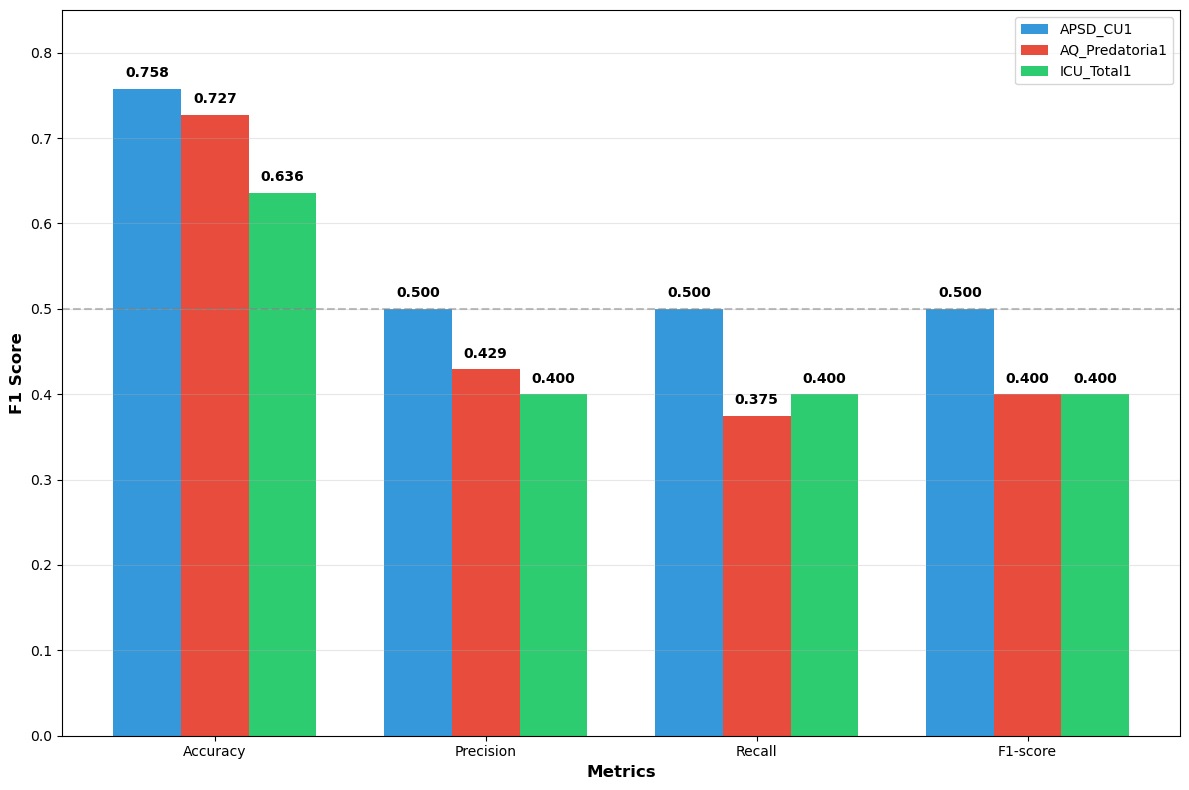

In [147]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Results data
results = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'APSD_CU1': [0.758, 0.500, 0.500, 0.500],
    'AQ_Predatoria1': [0.727, 0.429, 0.375, 0.400],
    'ICU_Total1': [0.636, 0.400, 0.400, 0.400]
}

df_results = pd.DataFrame(results)
print("MLP Model Performance Results")
print(df_results.to_string(index=False))

# Save table
df_results.to_csv('mlp_results.csv', index=False)
df_results.to_excel('mlp_results.xlsx', index=False)

# Create figure
fig, ax = plt.subplots(figsize=(12, 8))

metrics = df_results['Metric'].values
x = np.arange(len(metrics))
width = 0.25

bars1 = ax.bar(x - width, df_results['APSD_CU1'], width, label='APSD_CU1', color='#3498db')
bars2 = ax.bar(x, df_results['AQ_Predatoria1'], width, label='AQ_Predatoria1', color='#e74c3c')
bars3 = ax.bar(x + width, df_results['ICU_Total1'], width, label='ICU_Total1', color='#2ecc71')

# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.01, f'{height:.3f}', 
                ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('F1 Score', fontsize=12, fontweight='bold')
ax.set_xlabel('Metrics', fontsize=12, fontweight='bold')
ax.set_title('', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, 0.85)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Chance Level')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('mlp_performance.png', dpi=300, bbox_inches='tight')
plt.show()

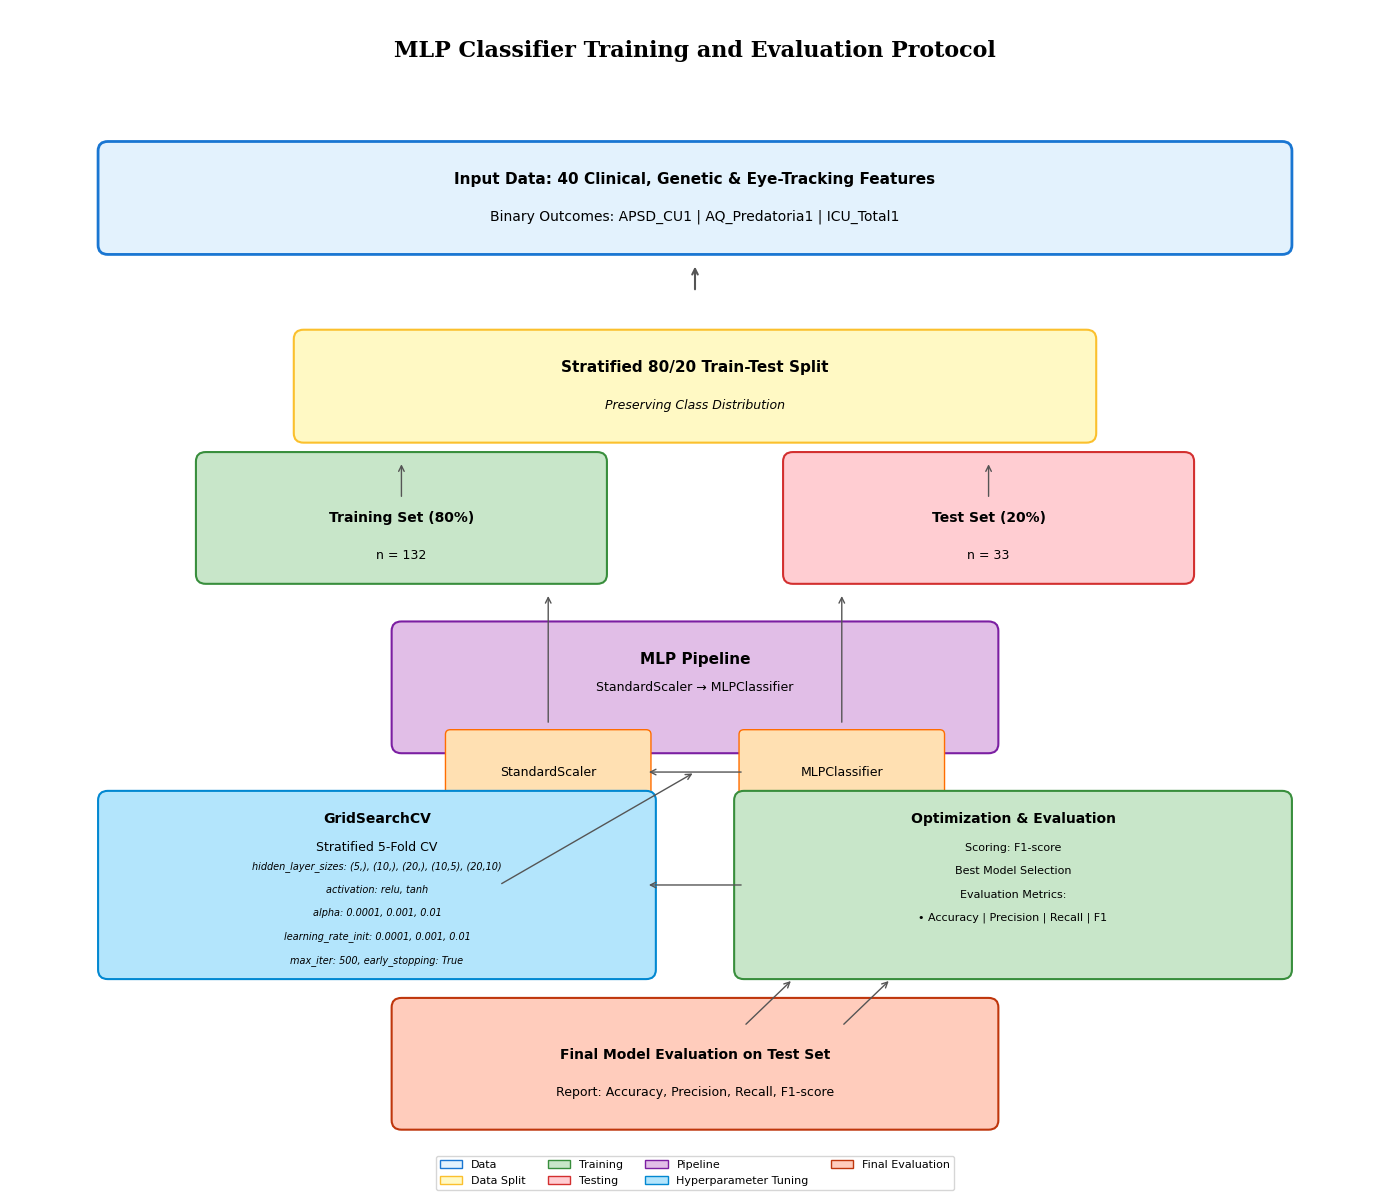

In [151]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Patch
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(14, 12))
ax.set_xlim(0, 14)
ax.set_ylim(0, 12)
ax.axis('off')

# Title
ax.text(7, 11.5, 'MLP Classifier Training and Evaluation Protocol', 
        fontsize=16, fontweight='bold', ha='center', fontfamily='serif')

# ============================================
# Step 1: Data Preparation
# ============================================
data_box = FancyBboxPatch((1, 9.5), 12, 1, boxstyle="round,pad=0.1",
                          facecolor='#e3f2fd', edgecolor='#1976d2', linewidth=2)
ax.add_patch(data_box)
ax.text(7, 10.2, 'Input Data: 40 Clinical, Genetic & Eye-Tracking Features', 
        ha='center', va='center', fontsize=11, fontweight='bold')
ax.text(7, 9.8, 'Binary Outcomes: APSD_CU1 | AQ_Predatoria1 | ICU_Total1', 
        ha='center', va='center', fontsize=10)

# Arrow down
ax.annotate('', xy=(7, 9.3), xytext=(7, 9.0), arrowprops=dict(arrowstyle='->', lw=1.5, color='#555'))

# ============================================
# Step 2: Train-Test Split
# ============================================
split_box = FancyBboxPatch((3, 7.5), 8, 1, boxstyle="round,pad=0.1",
                           facecolor='#fff9c4', edgecolor='#fbc02d', linewidth=1.5)
ax.add_patch(split_box)
ax.text(7, 8.2, 'Stratified 80/20 Train-Test Split', 
        ha='center', va='center', fontsize=11, fontweight='bold')
ax.text(7, 7.8, 'Preserving Class Distribution', 
        ha='center', va='center', fontsize=9, style='italic')

# Train and Test boxes
train_box = FancyBboxPatch((2, 6), 4, 1.2, boxstyle="round,pad=0.1",
                           facecolor='#c8e6c9', edgecolor='#388e3c', linewidth=1.5)
ax.add_patch(train_box)
ax.text(4, 6.6, 'Training Set (80%)', ha='center', va='center', fontsize=10, fontweight='bold')
ax.text(4, 6.2, 'n = 132', ha='center', va='center', fontsize=9)

test_box = FancyBboxPatch((8, 6), 4, 1.2, boxstyle="round,pad=0.1",
                          facecolor='#ffcdd2', edgecolor='#d32f2f', linewidth=1.5)
ax.add_patch(test_box)
ax.text(10, 6.6, 'Test Set (20%)', ha='center', va='center', fontsize=10, fontweight='bold')
ax.text(10, 6.2, 'n = 33', ha='center', va='center', fontsize=9)

# Arrow from split to train/test
ax.annotate('', xy=(4, 7.2), xytext=(4, 6.8), arrowprops=dict(arrowstyle='->', lw=1, color='#555'))
ax.annotate('', xy=(10, 7.2), xytext=(10, 6.8), arrowprops=dict(arrowstyle='->', lw=1, color='#555'))

# ============================================
# Step 3: Pipeline Architecture
# ============================================
pipeline_box = FancyBboxPatch((4, 4.2), 6, 1.2, boxstyle="round,pad=0.1",
                              facecolor='#e1bee7', edgecolor='#7b1fa2', linewidth=1.5)
ax.add_patch(pipeline_box)
ax.text(7, 5.1, 'MLP Pipeline', ha='center', va='center', fontsize=11, fontweight='bold')
ax.text(7, 4.8, 'StandardScaler → MLPClassifier', ha='center', va='center', fontsize=9)

# Components
scaler_box = FancyBboxPatch((4.5, 3.5), 2, 0.8, boxstyle="round,pad=0.05",
                            facecolor='#ffe0b2', edgecolor='#ff6d00', linewidth=1)
ax.add_patch(scaler_box)
ax.text(5.5, 3.9, 'StandardScaler', ha='center', va='center', fontsize=9)

mlp_box = FancyBboxPatch((7.5, 3.5), 2, 0.8, boxstyle="round,pad=0.05",
                         facecolor='#ffe0b2', edgecolor='#ff6d00', linewidth=1)
ax.add_patch(mlp_box)
ax.text(8.5, 3.9, 'MLPClassifier', ha='center', va='center', fontsize=9)

ax.annotate('', xy=(6.5, 3.9), xytext=(7.5, 3.9), arrowprops=dict(arrowstyle='->', lw=1, color='#555'))

# Arrow from train to pipeline
ax.annotate('', xy=(5.5, 5.8), xytext=(5.5, 4.4), arrowprops=dict(arrowstyle='->', lw=1, color='#555'))
ax.annotate('', xy=(8.5, 5.8), xytext=(8.5, 4.4), arrowprops=dict(arrowstyle='->', lw=1, color='#555'))

# ============================================
# Step 4: Hyperparameter Tuning (GridSearchCV)
# ============================================
tuning_box = FancyBboxPatch((1, 1.8), 5.5, 1.8, boxstyle="round,pad=0.1",
                            facecolor='#b3e5fc', edgecolor='#0288d1', linewidth=1.5)
ax.add_patch(tuning_box)
ax.text(3.75, 3.4, 'GridSearchCV', ha='center', va='center', fontsize=10, fontweight='bold')
ax.text(3.75, 3.1, 'Stratified 5-Fold CV', ha='center', va='center', fontsize=9)

# Hyperparameters list
hyperparams = [
    'hidden_layer_sizes: (5,), (10,), (20,), (10,5), (20,10)',
    'activation: relu, tanh',
    'alpha: 0.0001, 0.001, 0.01',
    'learning_rate_init: 0.0001, 0.001, 0.01',
    'max_iter: 500, early_stopping: True'
]

for i, param in enumerate(hyperparams):
    ax.text(3.75, 2.9 - i*0.25, param, ha='center', va='center', fontsize=7, style='italic')

# Arrow from pipeline to tuning
ax.annotate('', xy=(7, 3.9), xytext=(5, 2.7), arrowprops=dict(arrowstyle='->', lw=1, color='#555'))

# ============================================
# Step 5: Optimization & Evaluation
# ============================================
opt_box = FancyBboxPatch((7.5, 1.8), 5.5, 1.8, boxstyle="round,pad=0.1",
                         facecolor='#c8e6c9', edgecolor='#388e3c', linewidth=1.5)
ax.add_patch(opt_box)
ax.text(10.25, 3.4, 'Optimization & Evaluation', ha='center', va='center', fontsize=10, fontweight='bold')

opt_metrics = [
    'Scoring: F1-score',
    'Best Model Selection',
    'Evaluation Metrics:',
    '• Accuracy | Precision | Recall | F1'
]

for i, metric in enumerate(opt_metrics):
    ax.text(10.25, 3.1 - i*0.25, metric, ha='center', va='center', fontsize=8)

# Arrow from tuning to optimization
ax.annotate('', xy=(6.5, 2.7), xytext=(7.5, 2.7), arrowprops=dict(arrowstyle='->', lw=1, color='#555'))

# ============================================
# Step 6: Final Model & Test Evaluation
# ============================================
final_box = FancyBboxPatch((4, 0.2), 6, 1.2, boxstyle="round,pad=0.1",
                           facecolor='#ffccbc', edgecolor='#bf360c', linewidth=1.5)
ax.add_patch(final_box)
ax.text(7, 0.9, 'Final Model Evaluation on Test Set', ha='center', va='center', fontsize=10, fontweight='bold')
ax.text(7, 0.5, 'Report: Accuracy, Precision, Recall, F1-score', ha='center', va='center', fontsize=9)

# Arrow from optimization to final
ax.annotate('', xy=(9, 1.7), xytext=(8.5, 1.2), arrowprops=dict(arrowstyle='->', lw=1, color='#555'))
ax.annotate('', xy=(8, 1.7), xytext=(7.5, 1.2), arrowprops=dict(arrowstyle='->', lw=1, color='#555'))

# ============================================
# Legend
# ============================================
legend_elements = [
    Patch(facecolor='#e3f2fd', edgecolor='#1976d2', label='Data'),
    Patch(facecolor='#fff9c4', edgecolor='#fbc02d', label='Data Split'),
    Patch(facecolor='#c8e6c9', edgecolor='#388e3c', label='Training'),
    Patch(facecolor='#ffcdd2', edgecolor='#d32f2f', label='Testing'),
    Patch(facecolor='#e1bee7', edgecolor='#7b1fa2', label='Pipeline'),
    Patch(facecolor='#b3e5fc', edgecolor='#0288d1', label='Hyperparameter Tuning'),
    Patch(facecolor='#ffccbc', edgecolor='#bf360c', label='Final Evaluation')
]

ax.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.05),
          ncol=4, fontsize=8, frameon=True)

plt.tight_layout()
plt.savefig('mlp_protocol_diagram.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('mlp_protocol_diagram.pdf', bbox_inches='tight', facecolor='white')
plt.show()

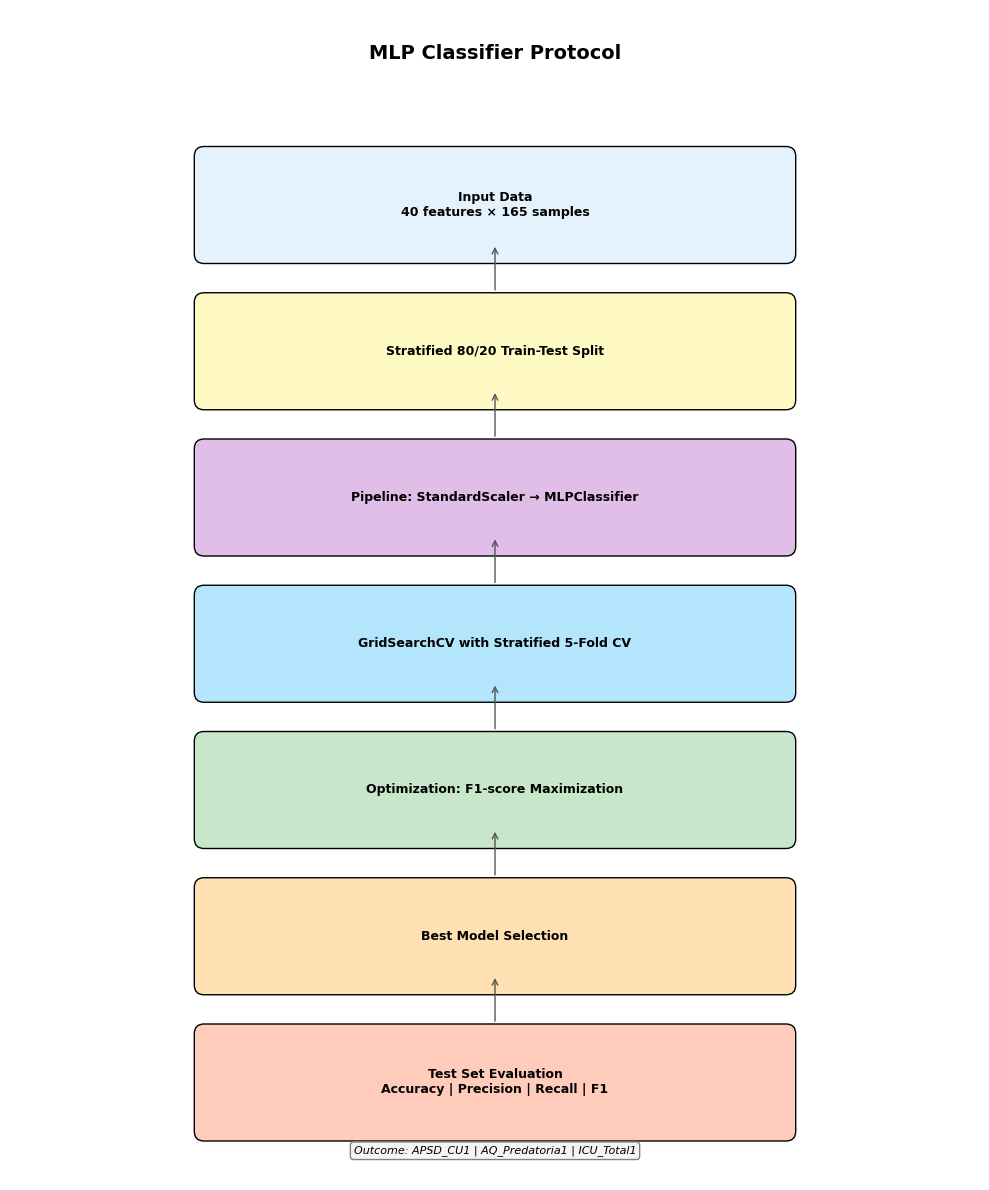

In [149]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(10, 12))
ax.set_xlim(0, 10)
ax.set_ylim(0, 12)
ax.axis('off')

# Title
ax.text(5, 11.5, 'MLP Classifier Protocol', fontsize=14, fontweight='bold', ha='center')

# Flow steps
steps = [
    (5, 10, 'Input Data\n40 features × 165 samples'),
    (5, 8.5, 'Stratified 80/20 Train-Test Split'),
    (5, 7, 'Pipeline: StandardScaler → MLPClassifier'),
    (5, 5.5, 'GridSearchCV with Stratified 5-Fold CV'),
    (5, 4, 'Optimization: F1-score Maximization'),
    (5, 2.5, 'Best Model Selection'),
    (5, 1, 'Test Set Evaluation\nAccuracy | Precision | Recall | F1')
]

colors = ['#e3f2fd', '#fff9c4', '#e1bee7', '#b3e5fc', '#c8e6c9', '#ffe0b2', '#ffccbc']

for i, (x, y, text) in enumerate(steps):
    box = FancyBboxPatch((x-3, y-0.5), 6, 1, boxstyle="round,pad=0.1",
                         facecolor=colors[i], edgecolor='black', linewidth=1)
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center', fontsize=9, fontweight='bold')
    
    # Add arrow between steps
    if i < len(steps) - 1:
        ax.annotate('', xy=(x, y-0.4), xytext=(x, y-0.9),
                   arrowprops=dict(arrowstyle='->', lw=1, color='#555'))

# Add outcome annotation
ax.text(5, 0.3, 'Outcome: APSD_CU1 | AQ_Predatoria1 | ICU_Total1',
        ha='center', va='center', fontsize=8, style='italic',
        bbox=dict(boxstyle='round', facecolor='#f5f5f5', edgecolor='gray'))

plt.tight_layout()
plt.savefig('mlp_protocol_simple.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

AUC: 0.71


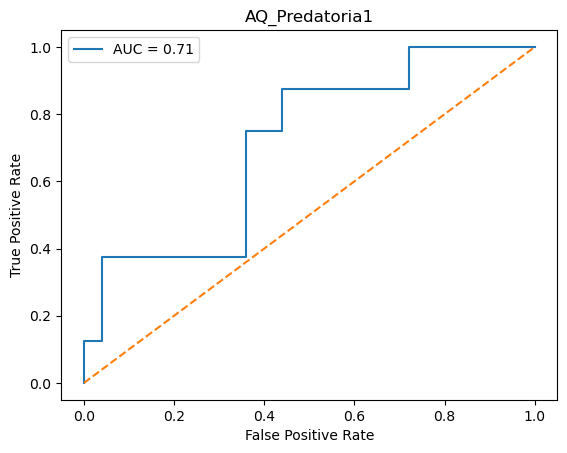

In [71]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get probabilities
y_prob = best_model.predict_proba(X_test)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test_1d, y_prob)

# Compute AUC
auc_score = roc_auc_score(y_test_1d, y_prob)

print("AUC:", auc_score)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--')  # random baseline

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AQ_Predatoria1')
plt.legend()

plt.show()

In [73]:
import numpy as np
from sklearn.feature_selection import RFE
from sklearn.model_selection import cross_val_score, StratifiedKFold

def rfe_with_cv(model, X, y, feature_names, min_features=2, n_splits=5):
    n_features = X.shape[1]
    history = []

    best_score = -np.inf
    best_features = None
    best_indices = None

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=1)

    for k in range(n_features, min_features - 1, -1):
        selector = RFE(model, n_features_to_select=k, step=1)
        X_selected = selector.fit_transform(X, y)

        scores = cross_val_score(model, X_selected, y, cv=cv, scoring='f1', n_jobs=-1)
        mean_score = scores.mean()

        selected_idx = np.where(selector.support_)[0]

        history.append({
            "n_features": k,
            "score": mean_score,
            "selected_idx": selected_idx
        })

        if mean_score > best_score:
            best_score = mean_score
            best_features = k
            best_indices = selected_idx

        print(f"Features: {k}, CV F1: {mean_score:.4f}")

    return best_indices, history

In [75]:
# Extract trained MLP (without scaler)
base_model = best_model.named_steps['mlp']

feature_names = X_train.columns.tolist()

selected_idx, rfe_history = rfe_with_cv(
    model=base_model,
    X=X_train,
    y=y_train_1d,
    feature_names=feature_names,
    min_features=2,
    n_splits=5
)

Features: 40, CV F1: 0.0000


ValueError: when `importance_getter=='auto'`, the underlying estimator MLPClassifier should have `coef_` or `feature_importances_` attribute. Either pass a fitted estimator to feature selector or call fit before calling transform.